<a href="https://colab.research.google.com/github/ALAAMEKAWY56/College-Clustering-Analysis-using-K-Means/blob/main/College_Clustering_Analysis_using_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Important imports for KMeans clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score , adjusted_rand_score ,

!pip install kneed
from kneed import KneeLocator

In [ ]:
from scipy.stats import skew

## Dataset Description: College Clustering Dataset

This dataset contains information about **777 universities and colleges** with **19 features** describing academic, financial, and demographic characteristics. It is commonly used for **clustering analysis (unsupervised learning)** to group similar institutions.

---

### General Information
- **Number of rows:** 777
- **Number of columns:** 19
- **Missing values:** None

---

### Features Description

#### General Information
- **University**: Name of the university (categorical)
- **Private**: Indicates whether the university is *Private* or *Public*

---

#### Admission & Enrollment
- **Apps**: Number of applications received
- **Accept**: Number of applications accepted
- **Enroll**: Number of new students enrolled

---

#### Academic Quality
- **Top10perc**: Percentage of students from top 10% of high school class
- **Top25perc**: Percentage of students from top 25% of high school class

---

#### Student Population
- **F.Undergrad**: Number of full-time undergraduate students
- **P.Undergrad**: Number of part-time undergraduate students

---

#### Financial Information
- **Outstate**: Out-of-state tuition fees
- **Room.Board**: Cost of room and board
- **Books**: Estimated book costs
- **Personal**: Estimated personal expenses

---

#### Faculty & Resources
- **PhD**: Percentage of faculty with PhDs
- **Terminal**: Percentage of faculty with terminal degrees
- **S.F.Ratio**: Student-to-faculty ratio

---

#### Performance & Spending
- **perc.alumni**: Percentage of alumni who donate
- **Expend**: Instructional expenditure per student
- **Grad.Rate**: Graduation rate

---

### Use Case
This dataset is ideal for:
- Clustering universities based on similar characteristics
- Identifying patterns between private and public institutions
- Exploring relationships between spending, quality, and graduation rates

---

### Notes
- Most features are **numerical**, making it suitable for algorithms like **KMeans**
- Categorical features (e.g., `Private`) may require encoding before modeling
- Feature scaling (e.g., StandardScaler) is recommended before clustering

---

# Feature Selection
Remove low variance features

Features with almost constant values → useless

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/College_Data.csv')
df

,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [ ]:
df.shape

(777, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   University   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

In [ ]:
df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [ ]:
df.isnull().sum()

,0
University,0
Private,0
Apps,0
Accept,0
Enroll,0
Top10perc,0
Top25perc,0
F.Undergrad,0
P.Undergrad,0
Outstate,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['University', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate'],
      dtype='object')

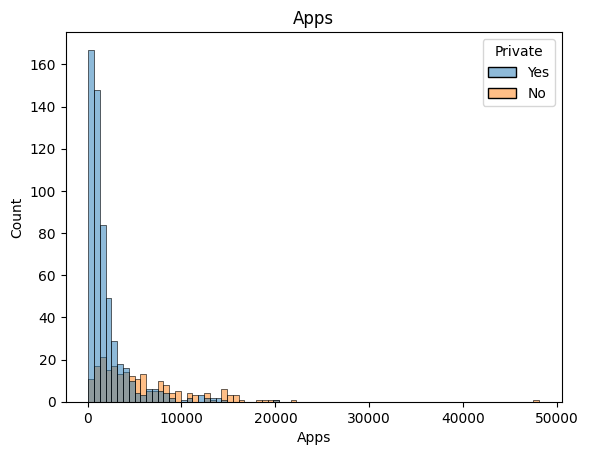

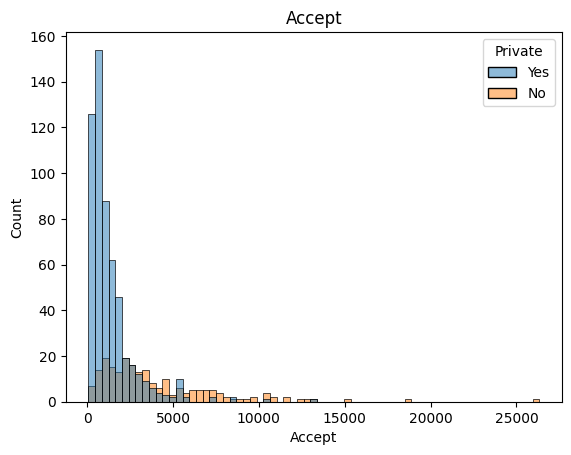

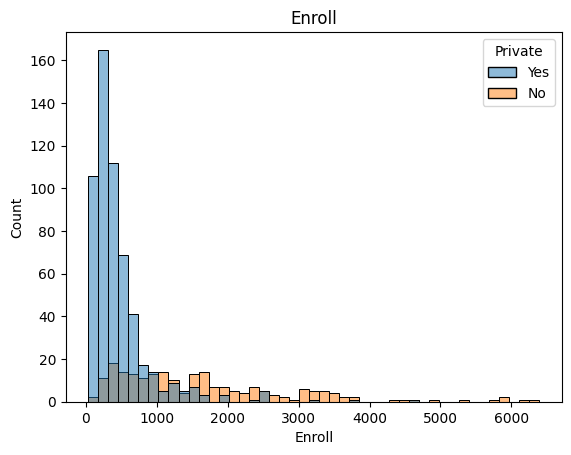

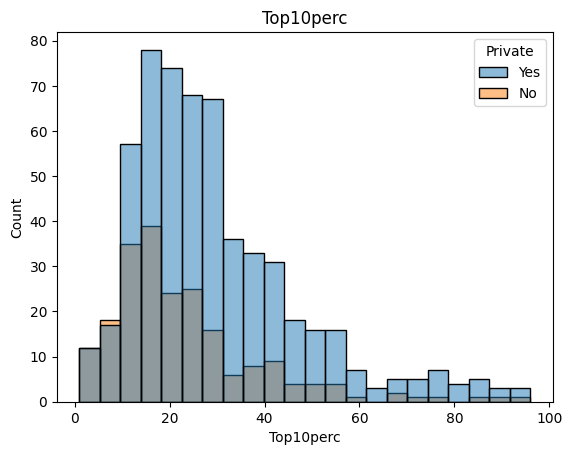

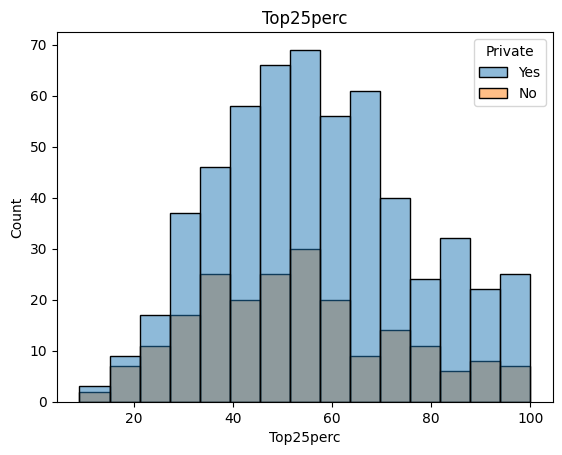

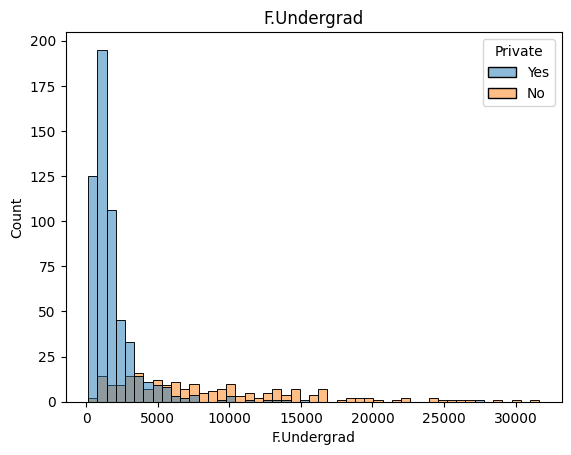

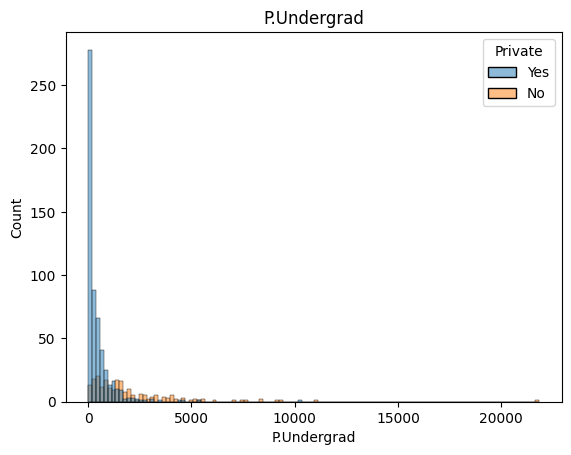

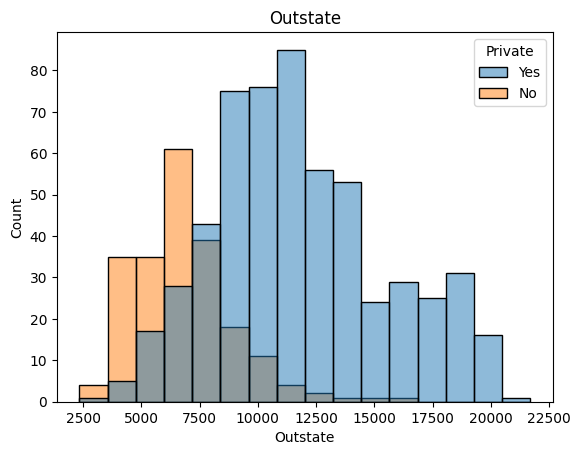

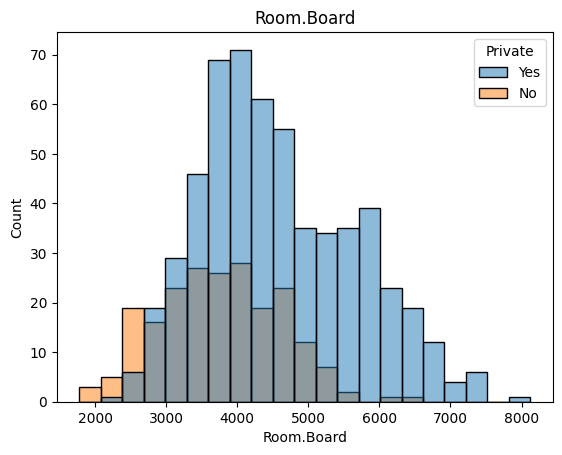

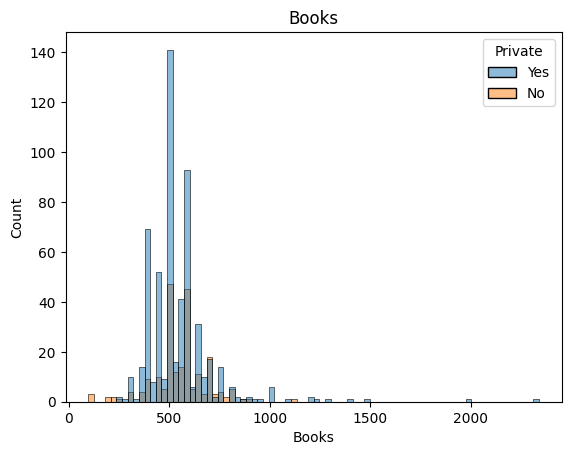

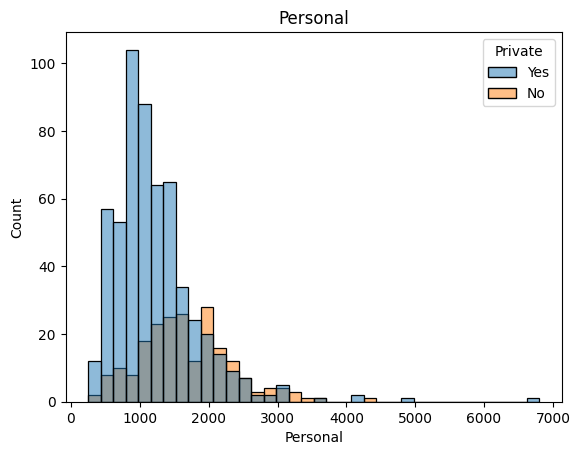

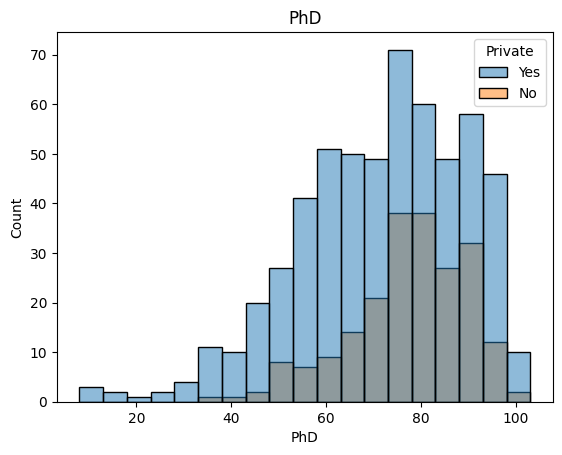

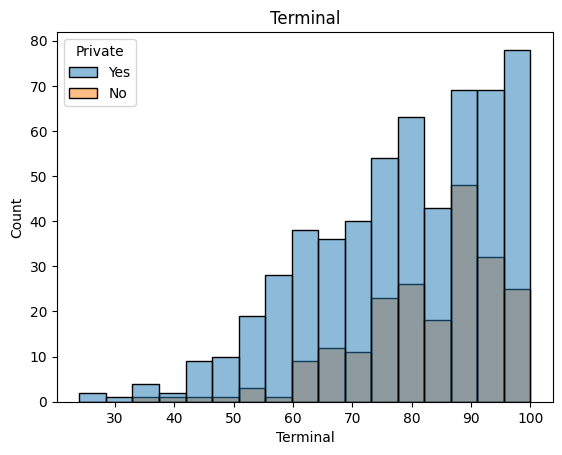

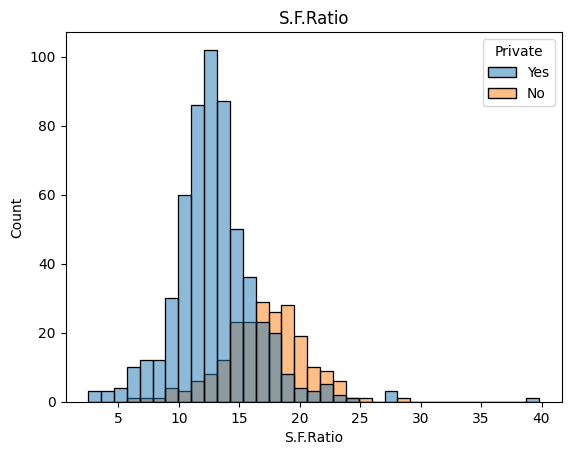

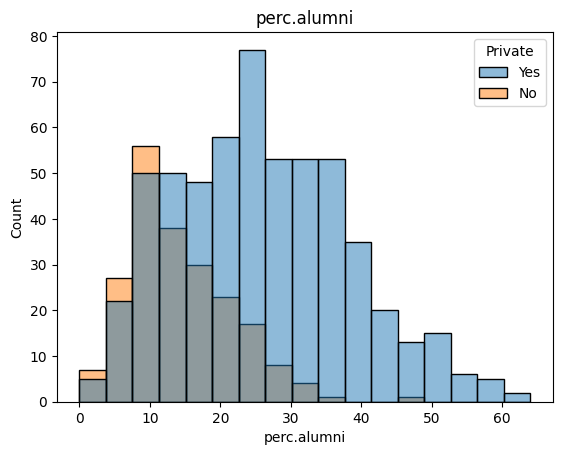

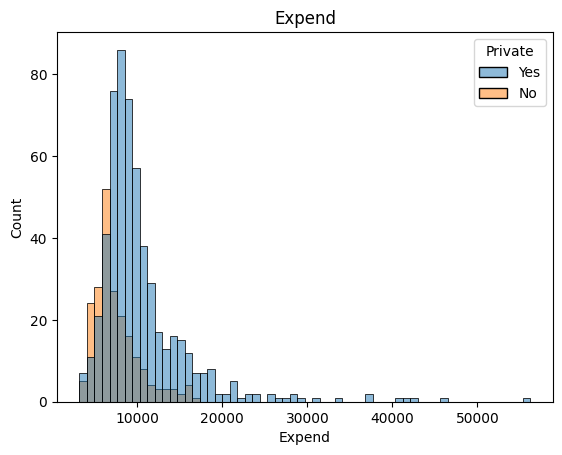

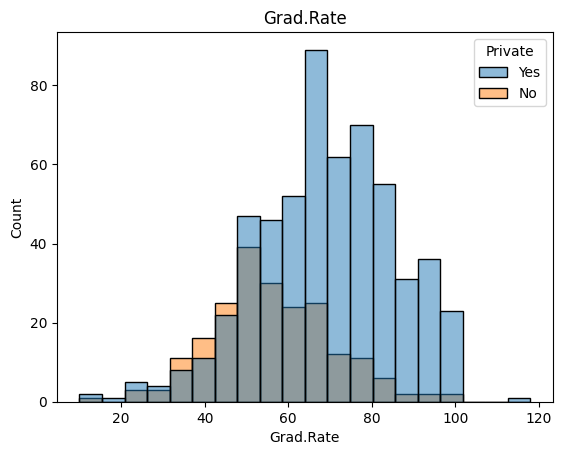

In [ ]:
for col in df.select_dtypes('number').columns:
  plt.figure()
  plt.title(col)
  sns.histplot(data = df , x = col , hue = 'Private')

# KMeans clustering is designed specifically for numerical data.
## Remove it or convert it

In [ ]:
df.drop(columns = ['University'] , inplace = True)

In [ ]:
df['Private'] = df['Private'].map({'Yes': 1, 'No': 0})

In [ ]:
# Save Private label BEFORE encoding for validation later
private_label = df['Private'].copy()

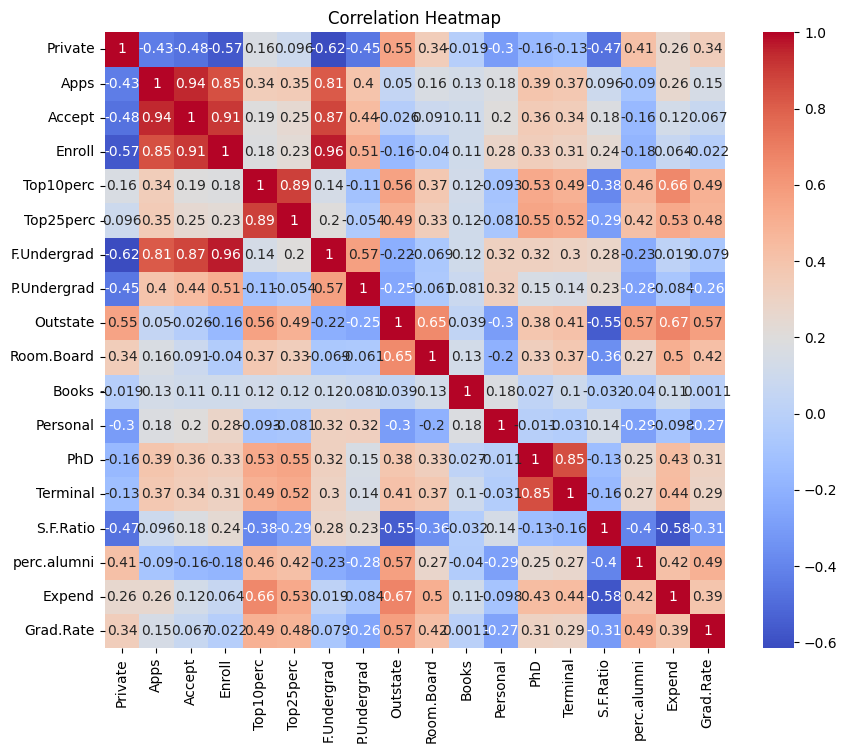

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm' , annot = True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
var_th = VarianceThreshold(threshold = 0)

In [ ]:
df = pd.DataFrame(var_th.fit_transform(df), columns=var_th.get_feature_names_out())

In [ ]:
df.shape

(777, 18)

In [ ]:
corr_matrix = df.corr().abs()
corr_matrix

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Private,1.000000,0.432095,0.475252,0.567908,0.164132,0.095752,0.615561,0.452088,0.552650,0.340532,0.018549,0.304485,0.156714,0.129620,0.472205,0.414775,0.258461,0.336162
Apps,0.432095,1.000000,0.943451,0.846822,0.338834,0.351640,0.814491,0.398264,0.050159,0.164939,0.132559,0.178731,0.390697,0.369491,0.095633,0.090226,0.259592,0.146755
Accept,0.475252,0.943451,1.000000,0.911637,0.192447,0.247476,0.874223,0.441271,0.025755,0.090899,0.113525,0.200989,0.355758,0.337583,0.176229,0.159990,0.124717,0.067313
Enroll,0.567908,0.846822,0.911637,1.000000,0.181294,0.226745,0.964640,0.513069,0.155477,0.040232,0.112711,0.280929,0.331469,0.308274,0.237271,0.180794,0.064169,0.022341
Top10perc,0.164132,0.338834,0.192447,0.181294,1.000000,0.891995,0.141289,0.105356,0.562331,0.371480,0.118858,0.093316,0.531828,0.491135,0.384875,0.455485,0.660913,0.494989
Top25perc,0.095752,0.351640,0.247476,0.226745,0.891995,1.000000,0.199445,0.053577,0.489394,0.331490,0.115527,0.080810,0.545862,0.524749,0.294629,0.417864,0.527447,0.477281
F.Undergrad,0.615561,0.814491,0.874223,0.964640,0.141289,0.199445,1.000000,0.570512,0.215742,0.068890,0.115550,0.317200,0.318337,0.300019,0.279703,0.229462,0.018652,0.078773
P.Undergrad,0.452088,0.398264,0.441271,0.513069,0.105356,0.053577,0.570512,1.000000,0.253512,0.061326,0.081200,0.319882,0.149114,0.141904,0.232531,0.280792,0.083568,0.257001
Outstate,0.552650,0.050159,0.025755,0.155477,0.562331,0.489394,0.215742,0.253512,1.000000,0.654256,0.038855,0.299087,0.382982,0.407983,0.554821,0.566262,0.672779,0.571290
Room.Board,0.340532,0.164939,0.090899,0.040232,0.371480,0.331490,0.068890,0.061326,0.654256,1.000000,0.127963,0.199428,0.329202,0.374540,0.362628,0.272363,0.501739,0.424942


In [ ]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
upper

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Private,NaN,0.432095,0.475252,0.567908,0.164132,0.095752,0.615561,0.452088,0.552650,0.340532,0.018549,0.304485,0.156714,0.129620,0.472205,0.414775,0.258461,0.336162
Apps,NaN,NaN,0.943451,0.846822,0.338834,0.351640,0.814491,0.398264,0.050159,0.164939,0.132559,0.178731,0.390697,0.369491,0.095633,0.090226,0.259592,0.146755
Accept,NaN,NaN,NaN,0.911637,0.192447,0.247476,0.874223,0.441271,0.025755,0.090899,0.113525,0.200989,0.355758,0.337583,0.176229,0.159990,0.124717,0.067313
Enroll,NaN,NaN,NaN,NaN,0.181294,0.226745,0.964640,0.513069,0.155477,0.040232,0.112711,0.280929,0.331469,0.308274,0.237271,0.180794,0.064169,0.022341
Top10perc,NaN,NaN,NaN,NaN,NaN,0.891995,0.141289,0.105356,0.562331,0.371480,0.118858,0.093316,0.531828,0.491135,0.384875,0.455485,0.660913,0.494989
Top25perc,NaN,NaN,NaN,NaN,NaN,NaN,0.199445,0.053577,0.489394,0.331490,0.115527,0.080810,0.545862,0.524749,0.294629,0.417864,0.527447,0.477281
F.Undergrad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.570512,0.215742,0.068890,0.115550,0.317200,0.318337,0.300019,0.279703,0.229462,0.018652,0.078773
P.Undergrad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.253512,0.061326,0.081200,0.319882,0.149114,0.141904,0.232531,0.280792,0.083568,0.257001
Outstate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.654256,0.038855,0.299087,0.382982,0.407983,0.554821,0.566262,0.672779,0.571290
Room.Board,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127963,0.199428,0.329202,0.374540,0.362628,0.272363,0.501739,0.424942


# Drop higly correleted values

In [ ]:
threshold = 0.95

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print("Highly correlated features to drop:", to_drop)

Highly correlated features to drop: ['F.Undergrad']


In [ ]:
df.drop(columns = to_drop , inplace = True)

In [ ]:
print("Remaining features:", df.columns)

Remaining features: Index(['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc',
       'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD',
       'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate'],
      dtype='object')


In [ ]:
df.shape

(777, 17)

# Log-Transform Skewed Features Instead of Removing Rows

we apply **log1p transformation** to all highly skewed features (|skewness| > 1.0):

`log1p(x) = log(1 + x)` — safe for zero values

In [ ]:
# Detect all skewed columns
skewed_cols = [col for col in df.select_dtypes('number').columns
                  if abs(skew(df[col])) > 1]
print('Skewed features to transform:', skewed_cols)

Skewed features to transform: ['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc', 'P.Undergrad', 'Books', 'Personal', 'Expend']


In [ ]:
# Apply log1p transformation
df_transformed = df.copy()
for col in skewed_cols:
  df_transformed[col] = np.log1p(df_transformed[col])

print('\nSkewness BEFORE transform:')
print(df[skewed_cols].apply(skew).round(2))
print('\nSkewness AFTER transform:')
print(df_transformed[skewed_cols].apply(skew).round(2))


Skewness BEFORE transform:
Private       -1.02
Apps           3.72
Accept         3.41
Enroll         2.69
Top10perc      1.41
P.Undergrad    5.68
Books          3.48
Personal       1.74
Expend         3.45
dtype: float64

Skewness AFTER transform:
Private       -1.02
Apps           0.19
Accept         0.18
Enroll         0.37
Top10perc     -0.43
P.Undergrad   -0.36
Books         -0.37
Personal      -0.11
Expend         0.84
dtype: float64


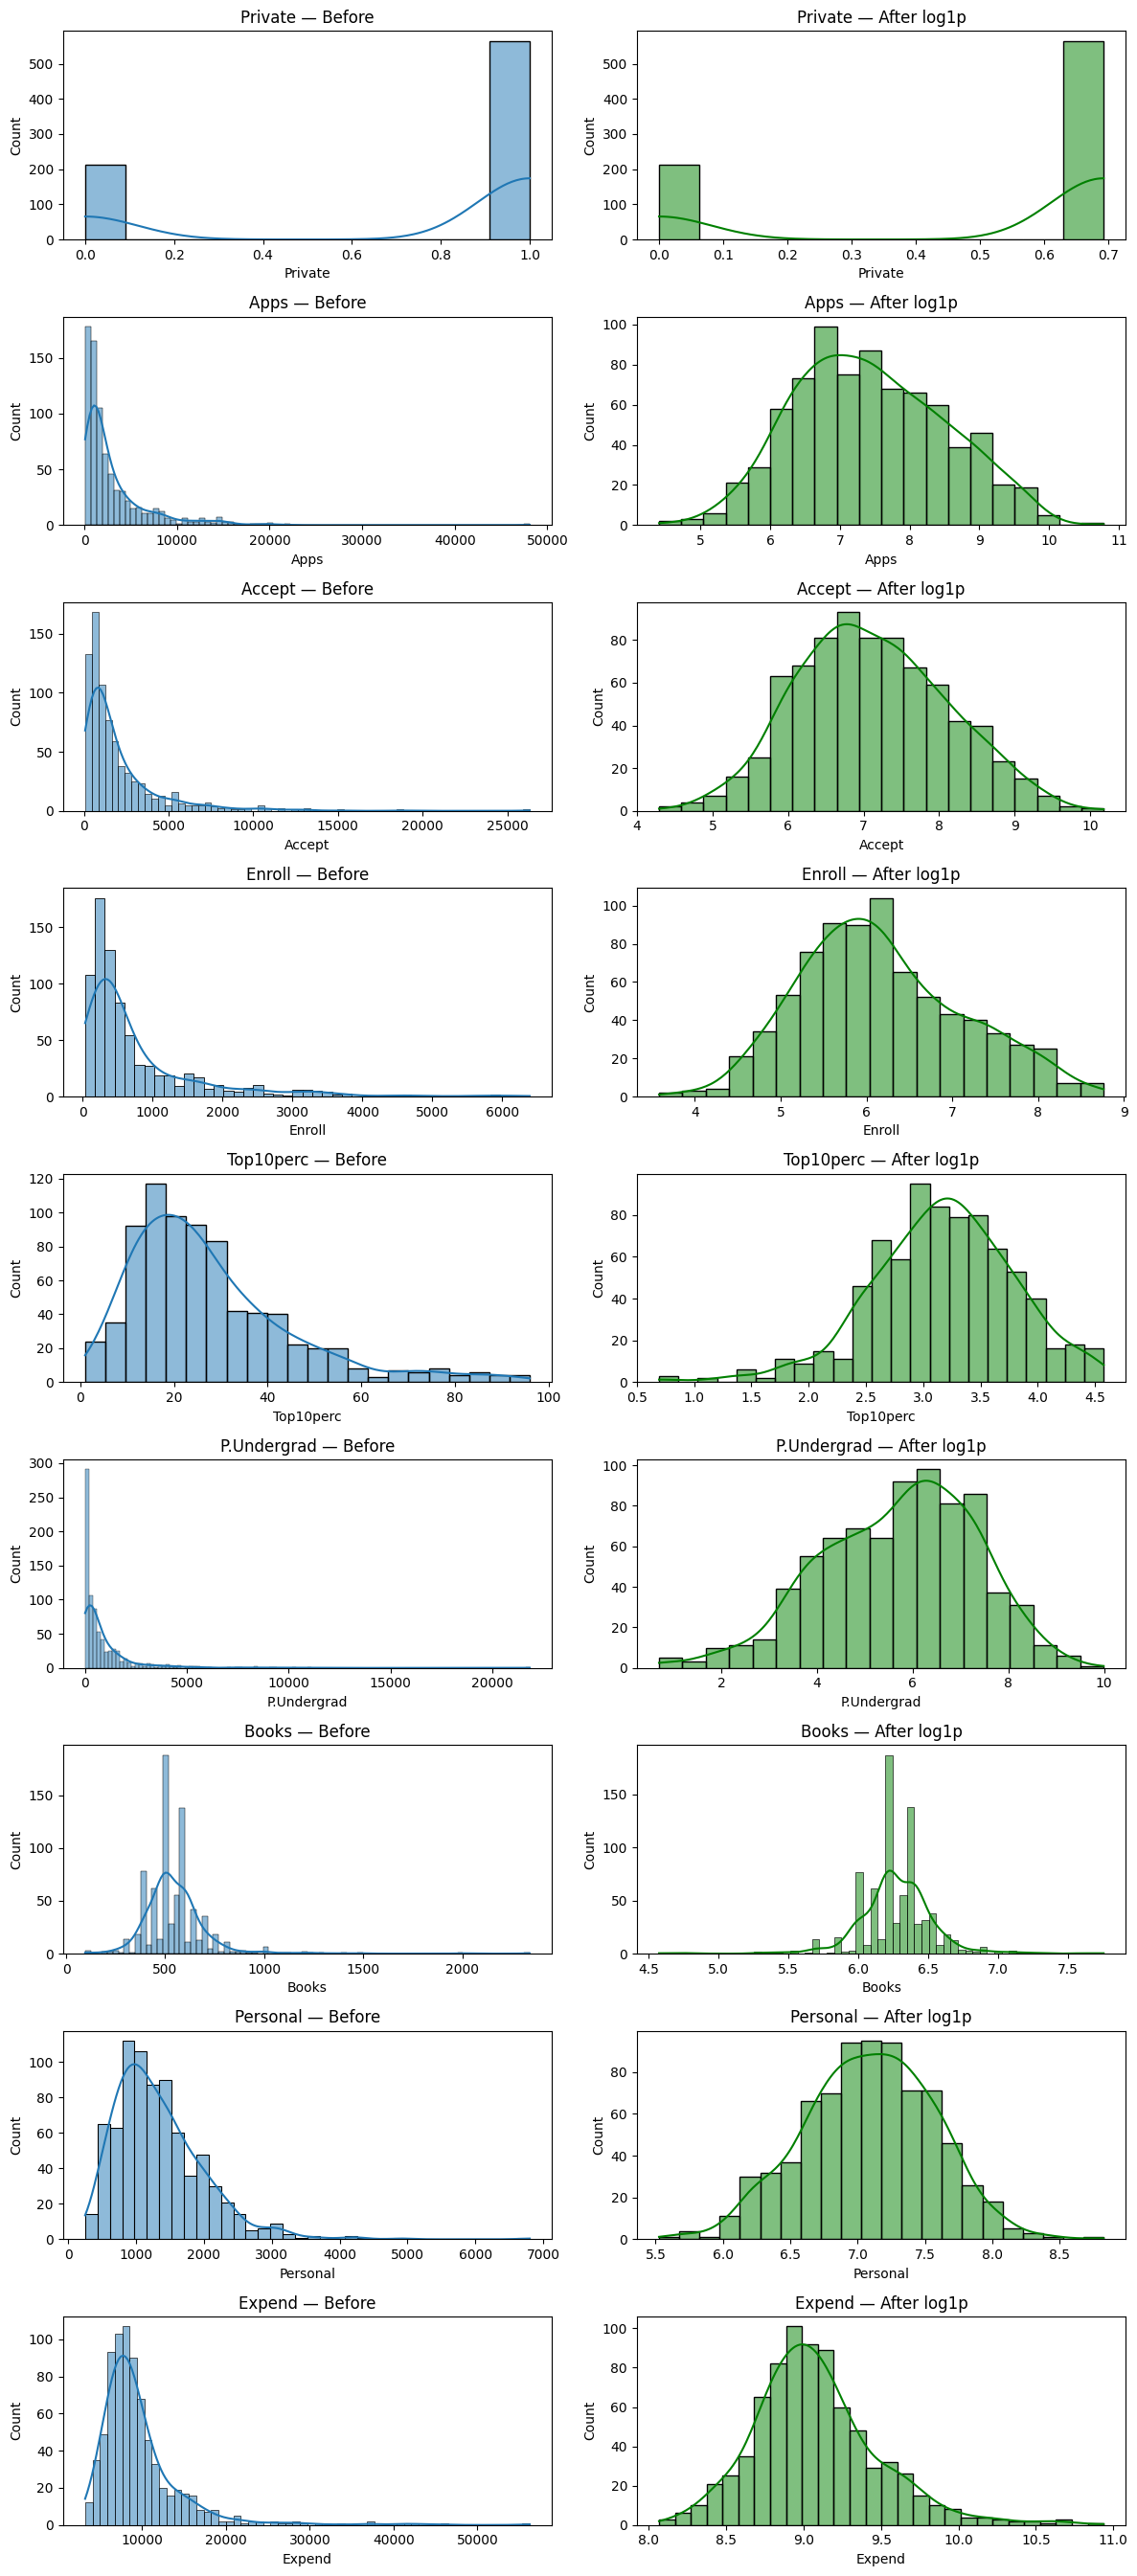

In [ ]:
# Visualize distributions before and after transformation
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(12, 3 * len(skewed_cols)))
for i, col in enumerate(skewed_cols):
    sns.histplot(df[col], ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f'{col} — Before')
    sns.histplot(df_transformed[col], ax=axes[i, 1], kde=True, color='green')
    axes[i, 1].set_title(f'{col} — After log1p')
plt.tight_layout()
plt.show()

In [ ]:
df = df_transformed.copy()
print('Final shape:' , df.shape)

Final shape: (777, 17)


In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
inertia_score, silhtte_scores = [], []

# Pre-scale data ONCE — use this consistently for both clustering and evaluation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

for k in range(2 , 20):
  kmeans = KMeans(n_clusters=k, random_state=10, n_init=10, init='k-means++')
  labels = kmeans.fit_predict(X_scaled)

  inertia_score.append(kmeans.inertia_)

  silhtte_scores.append(silhouette_score(X_scaled, labels))

In [ ]:
px.line(x=range(2, 20), y=inertia_score,
        title='Inertia (Elbow Method)',
        labels={'x': 'Number of Clusters (k)', 'y': 'Inertia'})

In [ ]:
px.line(x=range(2, 20), y=silhtte_scores,
        title='Silhouette Score by k',
        labels={'x': 'Number of Clusters (k)', 'y': 'Silhouette Score'})

In [ ]:
elbow_k = KneeLocator(range(2, 20), inertia_score, curve='convex', direction='decreasing').elbow
print('Elbow k:', elbow_k)

Elbow k: 5


In [ ]:
k = 3
kmeans_final = make_pipeline(StandardScaler() , KMeans(n_clusters=k , random_state= 10 , n_init=10 , init='k-means++'))

cluster_labels = kmeans_final.fit_predict(X_scaled)


In [ ]:
df_result = df.copy()
df_result['cluster'] = cluster_labels
df_result

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,cluster
0,0.693147,7.415175,7.117206,6.582025,3.178054,52.0,6.287859,7440.0,3300.0,6.111467,7.696667,70.0,78.0,18.1,12.0,8.859647,60.0,2
1,0.693147,7.690286,7.562681,6.240276,2.833213,29.0,7.113142,12280.0,6450.0,6.621406,7.313887,29.0,30.0,12.2,16.0,9.261794,56.0,2
2,0.693147,7.264730,7.001246,5.820083,3.135494,50.0,4.605170,11250.0,3750.0,5.993961,7.061334,53.0,66.0,12.9,30.0,9.075208,54.0,2
3,0.693147,6.035481,5.857933,4.927254,4.110874,89.0,4.158883,12960.0,5450.0,6.111467,6.775366,92.0,97.0,7.7,37.0,9.853089,59.0,1
4,0.693147,5.267858,4.990433,4.025352,2.833213,44.0,6.768493,7560.0,4120.0,6.685861,7.313887,76.0,72.0,11.9,2.0,9.298626,15.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0.000000,7.695303,7.323831,6.298949,1.609438,26.0,7.615791,6797.0,3900.0,6.216606,7.090910,60.0,60.0,21.0,14.0,8.405144,40.0,0
773,0.693147,7.580700,7.498870,6.545350,3.218876,47.0,7.010312,11520.0,4960.0,6.398595,7.131699,73.0,75.0,13.3,31.0,9.125871,83.0,1
774,0.693147,7.648740,7.557995,6.545350,3.555348,61.0,5.117994,6900.0,4200.0,6.426488,6.661855,67.0,75.0,14.4,20.0,9.026898,49.0,2
775,0.693147,9.278560,7.805475,7.183871,4.564348,99.0,4.430817,19840.0,6510.0,6.447306,7.657283,96.0,96.0,5.8,49.0,10.606263,99.0,1


In [ ]:
df_result.groupby('cluster').mean().round(2)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
cluster,,,,,,,,,,,,,,,,,
0,0.05,8.49,8.14,7.28,3.00,53.95,7.31,7024.80,3887.29,6.31,7.38,78.38,84.46,17.32,14.53,8.88,56.12
1,0.68,7.71,7.32,6.23,3.69,71.85,4.78,14677.31,5145.07,6.29,6.90,84.82,90.64,11.73,32.39,9.45,78.83
2,0.64,6.57,6.34,5.47,2.86,44.43,5.46,9197.25,4027.65,6.24,7.05,59.78,68.36,13.99,20.18,8.91,60.68


In [ ]:
sil   = silhouette_score(X_scaled, cluster_labels)
inertia = kmeans_final.named_steps['kmeans'].inertia_

print('=' * 45)
print(f'  Final k:               {k}')
print(f'  Silhouette Score:      {sil:.4f}  (higher is better, max=1)')
print(f'  Inertia:               {inertia:.2f}')
print('=' * 45)

  Final k:               3
  Silhouette Score:      0.2370  (higher is better, max=1)
  Inertia:               8017.37


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_result['PCA1'] = X_pca[:,0]
df_result['PCA2'] = X_pca[:,1]

In [ ]:
px.scatter(df_result, x='PCA1', y='PCA2',
           color= 'cluster',
           title=f'KMeans Clusters (k={k}) — PCA Projection',
           labels={'color': 'cluster'})